In [6]:
#loading the libraries and dataset 
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

In [14]:
import pandas as pd

df = pd.read_csv(r"C:\Users\Diksha\Downloads\archive\matches.csv")
df.head()

,match_id,date,venue,team1,team2,stage,toss_winner,toss_decision,first_ings_score,first_ings_wkts,...,match_result,match_winner,wb_runs,wb_wickets,balls_left,player_of_the_match,top_scorer,highscore,best_bowling,best_bowling_figure
0,1,"March 22,2025","Eden Gardens, Kolkata",KKR,RCB,League,RCB,Bowl,174.0,8.0,...,completed,RCB,NaN,7,22.0,Krunal Pandya,Virat Kohli,59.0,Krunal Pandya,3--29
1,2,"March 23,2025","Rajiv Gandhi International Stadium, Hyderabad",SRH,RR,League,RR,Bowl,286.0,6.0,...,completed,SRH,44,NaN,0.0,Ishan Kishan,Ishan Kishan,106.0,Tushar Deshpande,3--44
2,3,"March 23,2025","MA Chidambaram Stadium, Chennai",CSK,MI,League,CSK,Bowl,155.0,9.0,...,completed,CSK,NaN,4,5.0,Noor Ahmad,Rachin Ravindra,65.0,Noor Ahmad,4--18
3,4,"March 24,2025","ACA-VDCA Cricket Stadium, Vishakhapatnam",DC,LSG,League,DC,Bowl,209.0,8.0,...,completed,DC,NaN,1,3.0,Ashutosh Sharma,Nicholas Pooran,75.0,Mitchell Starc,3--42
4,5,"March 25,2025","Narendra Modi Stadium, Ahmedabad",GT,PBKS,League,GT,Bowl,243.0,5.0,...,completed,PBKS,11,NaN,0.0,Shreyas Iyer,Shreyas Iyer,97.0,Sai Kishore,3--30


In [15]:
print(f"your rows are{df.shape[0]} and your cloumns are {df.shape[1]}")

your rows are74 and your cloumns are 22


Text(0.5, 1.0, 'Most match win by team')

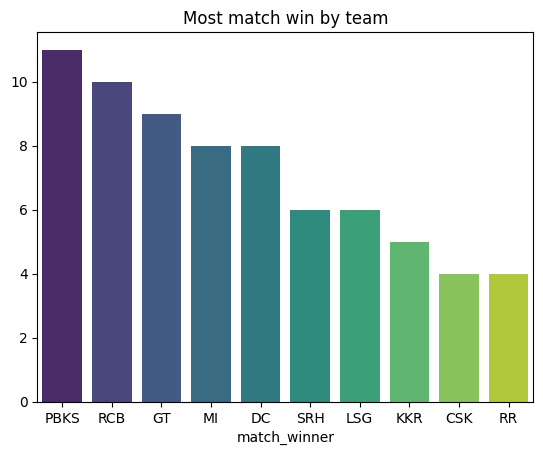

In [22]:
# which team won the most matches
match_wins =df['match_winner'].value_counts()
sns.barplot(x= match_wins.index, y= match_wins.values, palette='viridis')
plt.title("Most match win by team")

Text(0.5, 1.0, 'Toss decision trends')

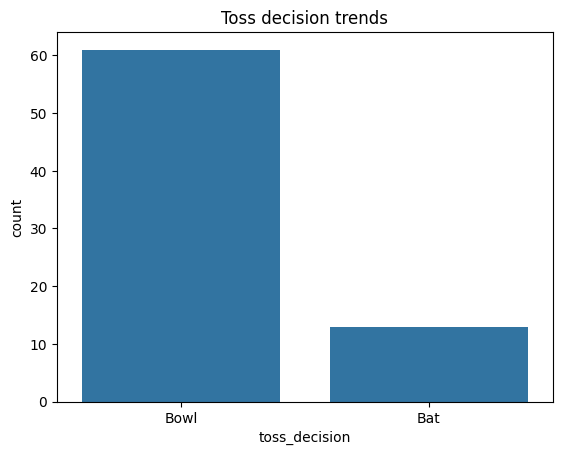

In [25]:
#toss decision trends 
sns.countplot(x=df['toss_decision'])
plt.title("Toss decision trends")

In [33]:
#toss winner vs match winner 
count = df[df['toss_winner'] == df['match_winner']]['match_id'].count()
percentage = (count * 100)/df.shape[0]
percentage.round(2)

np.float64(56.76)

In [39]:
#key player 
count = df['player_of_the_match'].value_counts().head(10)
count

player_of_the_match
Krunal Pandya        3
Shreyas Iyer         3
Ishan Kishan         2
Noor Ahmad           2
Prasidh Krishna      2
KL Rahul             2
Rajat Patidar        2
Prabhsimran Singh    2
Mitchell Starc       2
Mohammed Siraj       2
Name: count, dtype: int64

Text(0.5, 1.0, 'Top 10 with man of the match')

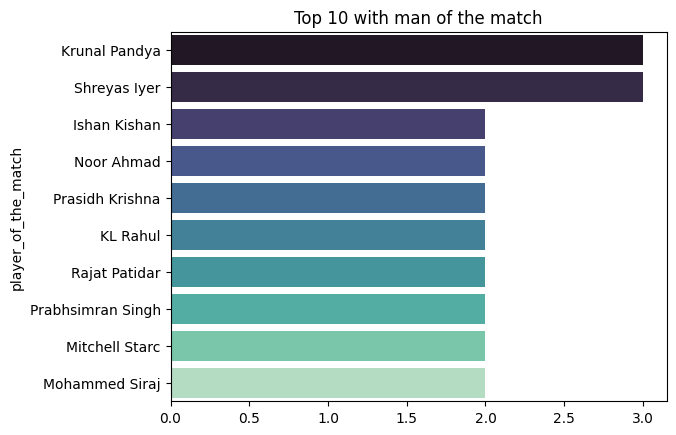

In [42]:
sns.barplot(x=count.values, y = count.index, palette = 'mako')
plt.title("Top 10 with man of the match")

In [50]:
high=df.groupby('top_scorer')['highscore'].sum().sort_values(ascending=False).head(2)
high

top_scorer
Nicholas Pooran    293.0
Virat Kohli        269.0
Name: highscore, dtype: float64

<Axes: ylabel='top_scorer'>

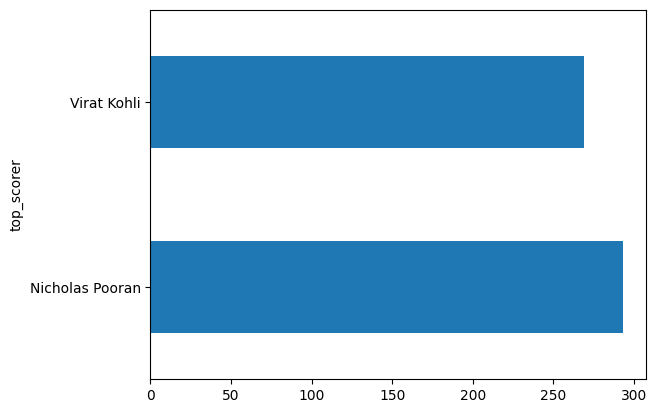

In [51]:
high.plot(kind ='barh')

<Axes: ylabel='best_bowling'>

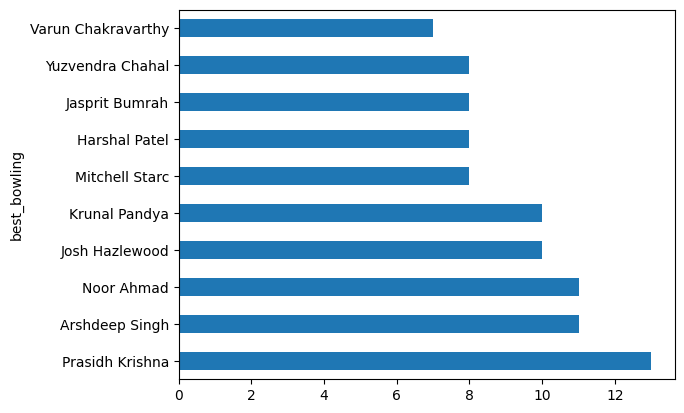

In [69]:
#10 best bowling figures 
df['highest_wickets']= df['best_bowling_figure'].apply(lambda x :x.split('--')[0])
df['highest_wickets'] = df['highest_wickets'].astype(int)
top_bowlers = df.groupby('best_bowling')['highest_wickets'].sum().sort_values(ascending=False).head(10)
top_bowlers.plot(kind = 'barh')

In [70]:
#venue Analysis 
#Most matches palyed by venue 
venue_count = df['venue'].value_counts()
venue_count



venue
Narendra Modi Stadium, Ahmedabad                 9
Ekana Cricket Stadium, Lucknow                   8
Sawai Mansingh Stadium, Jaipur                   7
Wankhede Stadium, Mumbai                         7
Arun Jaitley Stadium, Delhi                      7
New PCA Cricket Stadium, Mullanpur               6
Eden Gardens, Kolkata                            6
MA Chidambaram Stadium, Chennai                  6
Rajiv Gandhi International Stadium, Hyderabad    5
M. Chinnaswamy Stadium, Bangalore                5
ACA-VDCA Cricket Stadium, Vishakhapatnam         2
Barsapara Stadium, Guwahati                      2
HPCA Stadium, Dharamshala                        1
Name: count, dtype: int64

<Axes: ylabel='venue'>

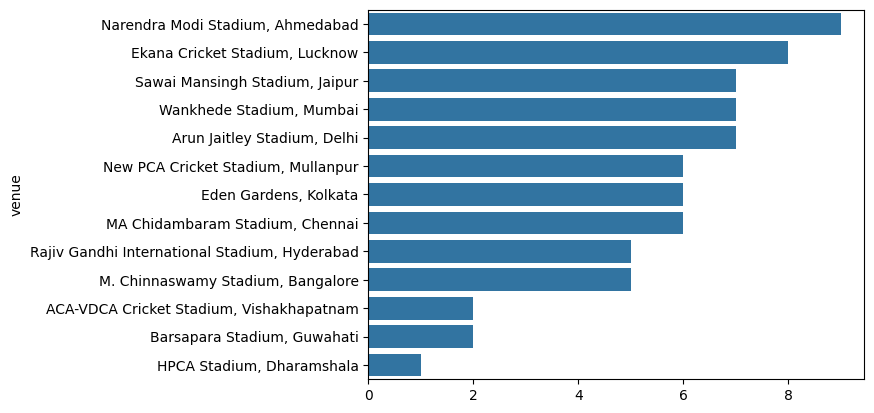

In [73]:
sns.barplot ( y= venue_count.index, x= venue_count.values )